In [435]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
from numpy.polynomial.chebyshev import chebvander, cheb2poly


In [436]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [1,2,0.1,0.6]
b_coeffs = ["4+0*s","5+0*s","6*exp(-s**4)",7]#"1/(1 + 25*s**2)"
#get bpmeth opbject
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is 0.0000112490703251815
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


Scalar potential phi(x,y,s): 0.025*x**4 + 0.0166666666666667*x**3 + x**2 + x + 0.025*y**4 - y**3*(72*s**2*x**2*(4*s**4 - 3)*exp(-s**4) + 42*x + 36*exp(-s**4))/36 - y**2*(7.2*x**2 + 2.4*x + 48)/48 + y*(7*x**3 + 18*x**2*exp(-s**4) + 30*x + 24)/6
Scalar potential phi at (0.4,0.2,0.5): 1.8155083831848042


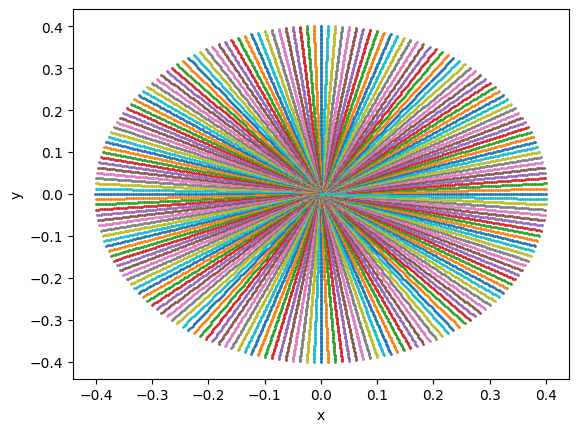

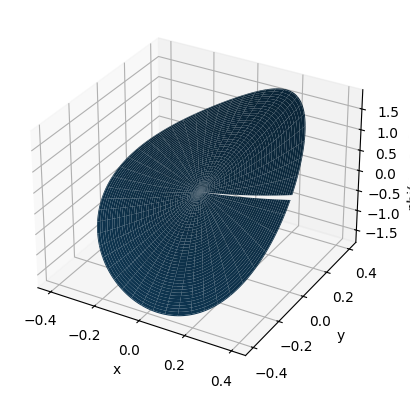

In [437]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define r, theta, s axes to convert the symbolic expression of phi into a numerical array
# npoints=201
# xa= np.linspace(-1,1,npoints) 
# ya=np.linspace(-1,1,npoints)
rmin, rmax, nr = 0.001, 0.401, 128
ntheta = 200
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, 40)

rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=1)
plt.xlabel("x")
plt.ylabel("y")
P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0],P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [438]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)
print(By_ana.shape)

(128, 200, 40)


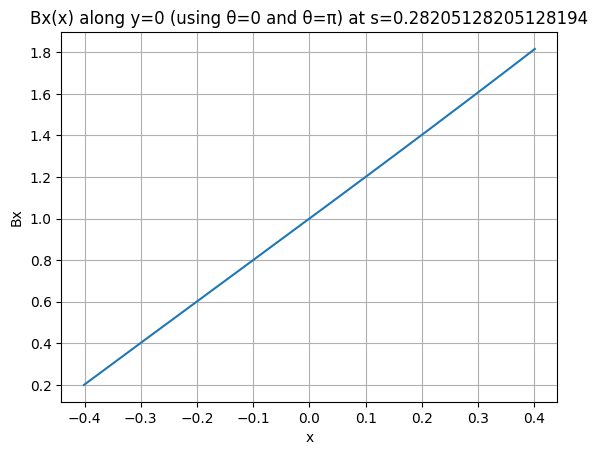

In [439]:
#Plot Bx as a function of x for y=0, fixed s
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
Bx_pos = Bx_ana[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
Bx_neg = Bx_ana[:, itheta_neg, :]

# Combine and sort
x_all = np.concatenate([x_neg, x_pos])
Bx_ofx = np.concatenate([Bx_neg, Bx_pos])

order = np.argsort(x_all[:,0])
x_all = x_all[order]
Bx_ofx = Bx_ofx[order]

plt.plot(x_all[:,islice], Bx_ofx[:,islice])
plt.xlabel("x")
plt.ylabel("Bx")
plt.title("Bx(x) along y=0 (using θ=0 and θ=π) at s="+str(ss[islice]))
plt.grid(True)


(256, 40) (256, 40)
(256, 40) (256, 40)


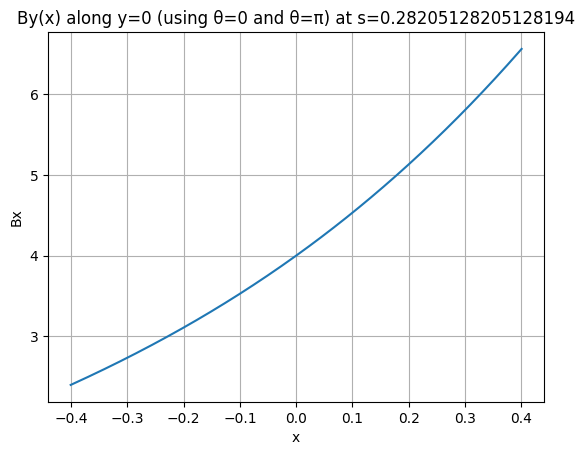

In [440]:
#Plot By as a function of x for y=0, fixed s
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
By_pos = By_ana[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
By_neg = By_ana[:, itheta_neg, :]
#print(x_neg.shape, By_neg.shape, x_pos.shape, By_pos.shape)
# Combine and sort
x_all = np.concatenate([x_neg, x_pos], axis=0)
By_ofx = np.concatenate([By_neg, By_pos])
print(x_all.shape, By_ofx.shape)
order = np.argsort(x_all[:,0])
x_all = x_all[order]
By_ofx = By_ofx[order]
print(x_all.shape, By_ofx.shape)
plt.plot(x_all[:,islice], By_ofx[:,islice])
plt.xlabel("x")
plt.ylabel("Bx")
plt.title("By(x) along y=0 (using θ=0 and θ=π) at s="+str(ss[islice]))
plt.grid(True)


In [441]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)#with lambdify False
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [442]:
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    #dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    #dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    #dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)
    def grad_periodic(f, dtheta, axis=1):
        return (np.roll(f, -1, axis=axis) - np.roll(f, 1, axis=axis)) / (2 * dtheta)

   #tell np.grad to use periodic boundary conditions for the theta derivative. otherwise at theta=0 it will use one-sided differences
    dAz_dtheta     = grad_periodic(Az_cyl, dtheta)
    dAr_dtheta     = grad_periodic(Ar,     dtheta)
    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_dz     = np.gradient(Ar,     ds, axis=2)
    dAtheta_dz = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_dz
    curl_theta = dAr_dz - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z
    #   # On the theta=pi/2 slice, curl_y ≈ curl_r (cos term vanishes)
    # # Decompose curl_r:
    # term1 = (1/rarr[:, itheta_pos, islice]) * dAz_dtheta[:, itheta_pos, islice]
    # term2 = dAtheta_dz[:, itheta_pos, islice]

    # plt.figure()
    
    # y_pos = yarr[:,itheta_pos, islice]
    # plt.plot(y_pos, term1, label='(1/r)*dAz_dtheta')
    # plt.plot(y_pos, term2, label='dAtheta_dz')
    # plt.plot(y_pos, term1 - term2, label='curl_r = curl_y')
    # plt.plot(y_pos, By_ana[:, itheta_pos, islice], label='By_ana')
    # plt.legend(); plt.grid(True)
    # plt.title("Decomposition of curl_y at theta=pi/2")
    # plt.show()
    # # Check curl_theta contribution (which vanishes at theta=pi/2 for curl_y)
    # ir_mid=nr//2
    # print("curl_theta at r=0.5, theta=pi/2:", curl_theta[ir_mid, itheta_pos, islice])
    # print("curl_r    at r=0.5, theta=pi/2:", curl_r[ir_mid,    itheta_pos, islice])
    # print("By_ana    at r=0.5, theta=pi/2:", By_ana[ir_mid,    itheta_pos, islice])
    # # Check if these are consistent
    # dAz_dx_direct = np.gradient(As_ana[:, itheta_pos, islice], 
    #                             xarr[:, itheta_pos, islice])  # direct x-derivative along the slice
    # dAz_dtheta_at_pos = dAz_dtheta[:, itheta_pos, islice]
    # r_at_pos = rarr[:, itheta_pos, islice]

    # plt.plot(yarr[:, itheta_pos, islice], dAz_dx_direct, label='dAz/dx direct')
    # plt.plot(yarr[:, itheta_pos, islice], -dAz_dtheta_at_pos / r_at_pos, label='-(1/r)*dAz/dtheta')
    # plt.legend(); plt.grid(True)
    # plt.show()
    # ir_max = -1  # outermost r
    # print("Ax at rmax:", Ax_ana[ir_max, itheta_pos, islice])
    # print("As at rmax:", As_ana[ir_max, itheta_pos, islice])
    # print("dAtheta_dz at rmax:", dAtheta_dz[ir_max, itheta_pos, islice])
    # print("dAz_dtheta/r at rmax:", dAz_dtheta[ir_max, itheta_pos, islice] / rmax)
    # # Compare numerical vs analytical dAx_ds at theta=pi/2
    # dAx_ds_numerical = np.gradient(Ax_ana[:, itheta_pos, :], ds, axis=1)

    # # If you have the symbolic derivative:
    # import sympy as sp
    # dAx_ds_sym = sp.diff(Ax, s)
    # dAx_ds_ana = np.vectorize(sp.lambdify([x, y, s], dAx_ds_sym, "numpy"))(
    #     xarr[:, itheta_pos, :], yarr[:, itheta_pos, :], sarr[:, itheta_pos, :]
    # )

    # plt.plot(rr, dAx_ds_numerical[:, islice], label='numerical dAx/ds')
    # plt.plot(rr, dAx_ds_ana[:, islice], label='analytical dAx/ds')
    # plt.legend(); plt.grid(True)
    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
#print(curl_x.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))




Max difference in Bx: 0.010785455019156842
Max relative difference in By: 0.006341280080210434
Max difference in Bs: 0.001963449764964237


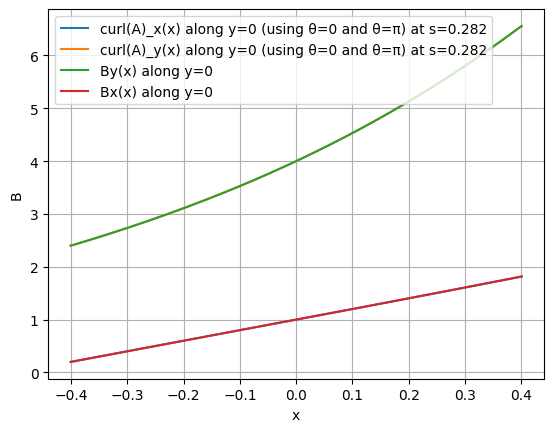

In [443]:
#Plot curlx as a function of x for y=0
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
curlx_pos = curl_x[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
curlx_neg = curl_x[:, itheta_neg, :]

# Combine and sort
x_all = np.concatenate([x_neg, x_pos])
curlx_ofx = np.concatenate([curlx_neg, curlx_pos])

order = np.argsort(x_all[:,0])
x_all = x_all[order]
curlx_ofx = curlx_ofx[order]

plt.plot(x_all[:,islice], curlx_ofx[:,islice], label="curl(A)_x(x) along y=0 (using θ=0 and θ=π) at s="+str(f"{ss[islice]:.3f}"))
plt.xlabel("x")
plt.ylabel("B")

plt.grid(True)
#plot curly as a function of x for y=0

curly_pos = curl_y[:, itheta_pos, :]
curly_neg = curl_y[:, itheta_neg, :]

# Combine and sort
curly_ofx = np.concatenate([curly_neg, curly_pos])
curly_ofx = curly_ofx[order]

plt.plot(x_all[:,islice], curly_ofx[:,islice], label="curl(A)_y(x) along y=0 (using θ=0 and θ=π) at s="+str(f"{ss[islice]:.3f}"))
plt.plot(x_all[:,islice], By_ofx[:,islice], label='By(x) along y=0')
plt.plot(x_all[:,islice], Bx_ofx[:,islice], label='Bx(x) along y=0')
plt.legend()
# plt.xlim((-.01,.6))
# plt.ylim((0.99,1.1))
plt.show()



(128, 200, 40)
0


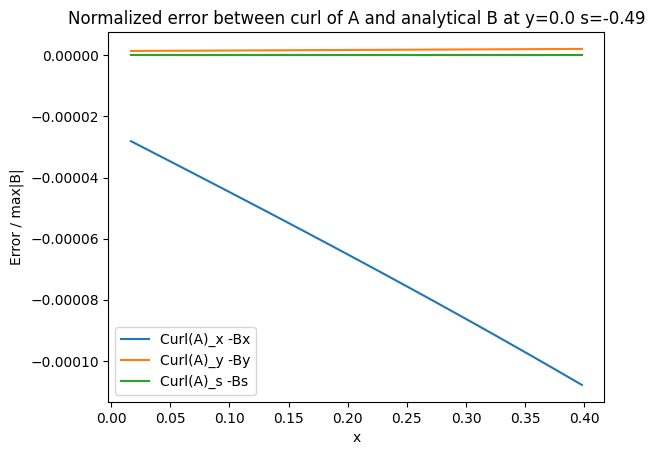

In [444]:
npoints=len(xarr)
print(xarr.shape)
truncatedxarr=xarr[5:npoints-1,0,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(5,npoints-1), 0, 10)#all x, y=fixed, s=fixed
print(position[1])
Bmaxx=np.max([np.max(Bx_ana),np.max(By_ana),np.max(Bs_ana)])
plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/Bmaxx, label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/Bmaxx, label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/Bmaxx, label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_y[position]-By_ana[position])/By_ana[position]), np.max((curl_y[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Normalized error between curl of A and analytical B at y='+str(np.round(yarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.ylabel('Error / max|B|')
plt.show()


Text(0.5, 0, 'x')

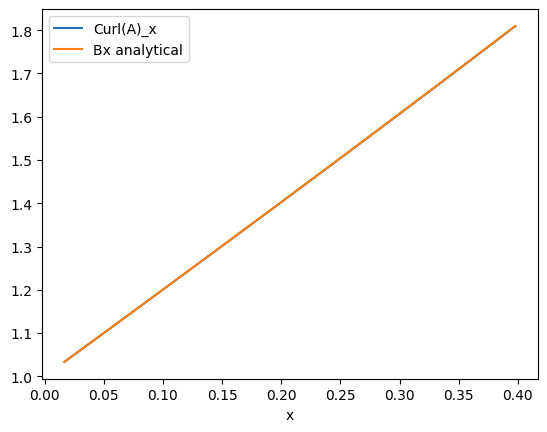

In [445]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

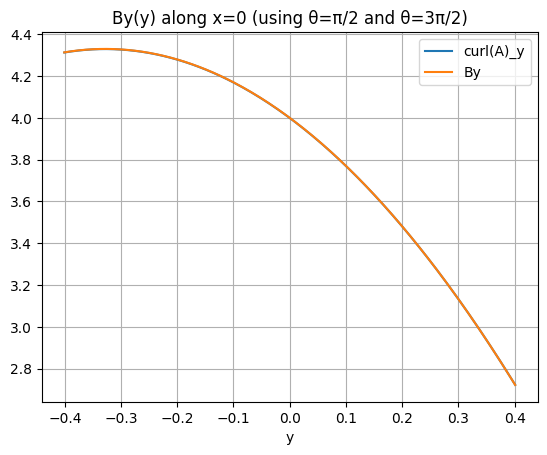

In [446]:
#plot y component of field as function of y for x=0
islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]
By_pos= By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]
By_neg= By_ana[:, itheta_neg, islice]
# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
By_all = np.concatenate([By_neg, By_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]
By_all =By_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")

plt.legend()
plt.grid(True)


HA of curl(A) (on the grid)

In [447]:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitrawcut(dkofrarray, rr, nk, nl, rmin_fit=None):
    '''
    rmin_fit: minimum r to include in the fit (to avoid blow-up of dk/r^|k| at small r).
              Defaults to rr.max() * 0.6 if not given.
    '''
    if rmin_fit is None:
        rmin_fit = rr.max() * 0.6

    mask = rr >= rmin_fit
    rr_fit = rr[mask]
    dkofr_fit = dkofrarray[mask, :]

    polynomial = np.zeros((len(rr_fit), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_fit):
        polynomial[ir, 0]    = dkofr_fit[ir, 0]
        polynomial[ir, 1::2] = dkofr_fit[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofr_fit[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_fit**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfitraw_nodiv(dkofrarray, rr, nk, nl):
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    kpos = np.arange(1, nk+1)

    # k=0: exponents are 0, 2, 4, ..., 2*(nl-1)
    V0 = np.column_stack([rr**(2*l) for l in range(nl)])
    dkl[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(kpos):
        # exponents are k, k+2, k+4, ..., k+2*(nl-1)
        V = np.column_stack([rr**(k + 2*l) for l in range(nl)])
        col_pos = 2*ik + 1
        col_neg = 2*ik + 2
        dkl[col_pos, :] = np.linalg.lstsq(V, dkofrarray[:, col_pos], rcond=None)[0]
        dkl[col_neg, :] = np.linalg.lstsq(V, dkofrarray[:, col_neg], rcond=None)[0]

    return dkl
def dklfitrenormalized(dkofrarray, rr, nk, nl):#not useful
    '''
    renormalizes all r values to rref=2/3 rmax
    '''
   

    
    rr_ren = rr/rr[len(rr)*2//3]
    

    polynomial = np.zeros((len(rr_ren), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_ren):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_ren**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfit_cheb(dkofrarray, rr, nk, nl):
    '''
    Same as dklfit but fits in the Chebyshev basis for better numerical stability.
    The fit variable is x = r^2, mapped to [-1, 1] for the Chebyshev domain.
    
    Returns: dkl in the MONOMIAL basis (same layout as dklfit),
             converted from Chebyshev coefficients via cheb2poly.
    '''
    polynomial = np.zeros((len(rr), 2*nk+1), dtype=complex)
    ka = np.linspace(-nk, nk, 2*nk+1)

    for ir, r in enumerate(rr):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**ka[nk+1 : 2*nk+1]
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**-ka[0: nk]

    # Map r^2 to [-1, 1] for Chebyshev domain
    x = rr**2
    x_min, x_max = x.min(), x.max()
    x_scaled = 2 * (x - x_min) / (x_max - x_min) - 1  # in [-1, 1]

    # Chebyshev Vandermonde matrix: shape (len(rr), nl)
    V = chebvander(x_scaled, nl - 1)

    # Fit all k-columns at once
    cheb_coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)
    # cheb_coeffs shape: (nl, 2*nk+1)

    # Convert each k column from Chebyshev to monomial basis
    # cheb2poly works on real arrays, so handle real/imag separately
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    for ik in range(2*nk+1):
        mono_re = cheb2poly(cheb_coeffs[:, ik].real)
        mono_im = cheb2poly(cheb_coeffs[:, ik].imag)
        dkl[ik, :] = mono_re + 1j * mono_im

    return dkl

def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):
    '''
    Numerically stable version of dklfitraw_nodiv.
    Fits dk(r) = sum_l d_kl * r^(k+2l) directly (no division by r^k),
    using rn = rr/rr.max() to keep basis values in (0,1].
    
    The d_kl returned are in the original (unnormalized) r basis,
    i.e. the r0 scaling is absorbed back into the coefficients.
    '''
    r0 = rr.max()
    rn = rr / r0    # in (0, 1]

    dkl_norm = np.zeros((2*nk+1, nl), dtype=complex)

    # k=0: basis is rn^0, rn^2, rn^4, ...
    V0 = np.column_stack([rn**(2*l) for l in range(nl)])
    dkl_norm[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(np.arange(1, nk+1)):
        V = np.column_stack([rn**(k + 2*l) for l in range(nl)])
        dkl_norm[2*ik+1, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+1], rcond=None)[0]
        dkl_norm[2*ik+2, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+2], rcond=None)[0]

    # Rescale: since rn = r/r0, rn^(k+2l) = r^(k+2l) / r0^(k+2l)
    # so d_kl_norm = d_kl * r0^(k+2l) → d_kl = d_kl_norm / r0^(k+2l)
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    dkl[0, :] = dkl_norm[0, :] / r0**(2*np.arange(nl))

    for ik, k in enumerate(np.arange(1, nk+1)):
        scale = r0**(k + 2*np.arange(nl))
        dkl[2*ik+1, :] = dkl_norm[2*ik+1, :] / scale
        dkl[2*ik+2, :] = dkl_norm[2*ik+2, :] / scale

    return dkl
#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_cut(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitrawcut(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_nodiv(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn


s fixed= 0.28205128205128194


/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


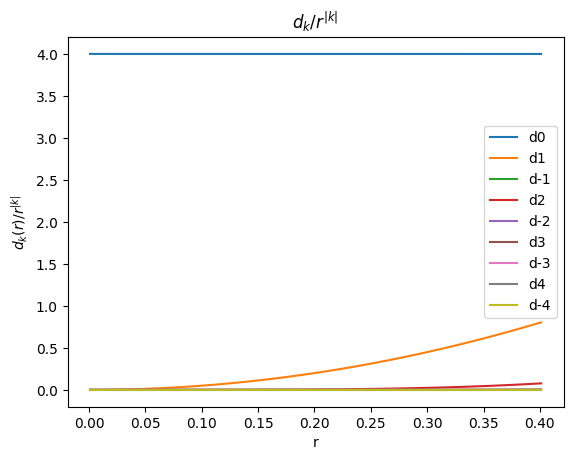

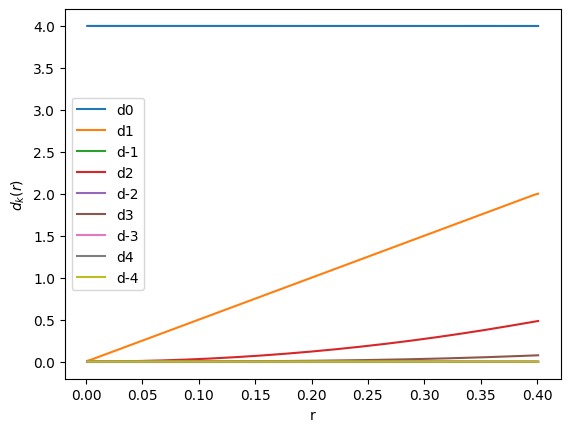

In [448]:
nk=4
nl=nk//2+1
sindex=25
s_fixed=ss[sindex]
print("s fixed=",s_fixed)
curlyix=curl_y+1j*curl_x
#origByiBx=By_ana+1j*Bx_ana #to check from the original field
dkgridout=dkongrid(Byibx_rts=curlyix, rr=rr, nk=nk,s_index=25)
#plot dk(r)/r^|k|
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki+1)/2), label='d'+str((ki+1)//2))#for some reason i have to put a - in the exponent
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki)/2), label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)/r^{|k|}$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title('$d_k/r^{|k|}$')
plt.show()
#plot d_k(r)
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str((ki+1)//2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.show()


In [449]:

griddkl_nodiv_cheb=dklfitraw_nodiv_cheb(dkofrarray=dkgridout ,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(griddkl_nodiv_cheb)
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
b_eva = lambdify(s, b_coeffs, 'numpy')
a_eva = lambdify(s, a_coeffs, 'numpy')


#recover them with different variation of the HA method:
acurl_nodiv_cheb, bcurl_nodiv_cheb = LHongrid_nodiv_cheb(ByiBxongrid=curlyix, s_index=25, nk=nk)
acurlcut, bcurl_cut = LHongrid_cut(ByiBxongrid=curlyix, s_index=25, nk=nk)
acurl_nodiv, bcurl_nodiv = LHongrid_nodiv(ByiBxongrid=curlyix, s_index=25, nk=nk)
print("a_n from curl by no div cheb", acurl_nodiv_cheb)
print("b_n from curl by no div cheb", bcurl_nodiv_cheb)
print(f"original a_n(s={s_fixed:.3f}) = {a_eva(s_fixed)}")
print(f"original b_n(s={s_fixed:.3f}) = {b_eva(s_fixed)}")
print("a_n from curl by cut", acurlcut)
print("b_n from curl by cut", bcurl_cut)
print("a_n from curl by no div", acurl_nodiv)
print("b_n from curl by no div", bcurl_nodiv)

columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[ 4.   +1.j     0.002+0.j    -0.031-0.j   ]
 [ 4.997+1.999j  0.035+0.014j -0.237-0.095j]
 [-0.   +0.j     0.   -0.j    -0.   +0.j   ]
 [ 2.976+0.05j   0.323+0.001j -0.477-0.008j]
 [ 0.018-0.005j -0.249+0.062j  0.992-0.237j]
 [ 1.161+0.1j    0.092+0.008j -0.483-0.041j]
 [ 0.03 -0.012j  0.076-0.03j  -1.741+0.697j]
 [-0.177+0.j     0.059-0.j     0.062+0.j   ]
 [-0.06 -0.j     0.905-0.013j -5.355+0.087j]]
a_n from curl by no div cheb [1.    1.999 0.091 0.607]
b_n from curl by no div cheb [4.    4.997 5.992 7.358]
original a_n(s=0.282) = [1, 2, 0.1, 0.6]
original b_n(s=0.282) = [np.float64(4.0), np.float64(5.0), np.float64(5.962147895108964), 7]
a_n from curl by cut [1.    1.997 0.095 0.808]
b_n from curl by cut [4.    4.993 5.976 7.74 ]
a_n from curl by no div [1.    1.999 0.091 0.607]
b_n from curl by no div [4.    4.997 5.992 7.358]


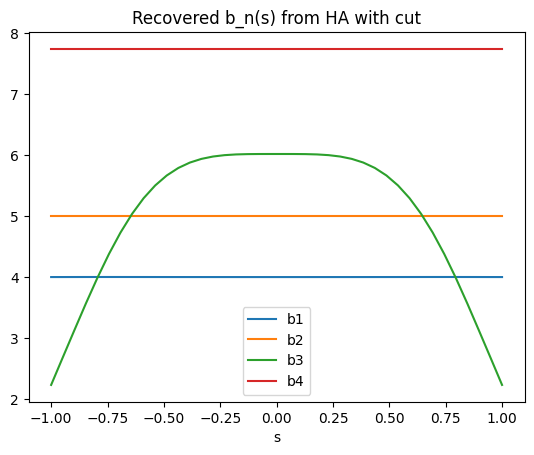

In [450]:
#HA as a function of s:
def LH_s_grid(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid_cut(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs
sss, bofs_cut = LH_s_grid(fieldyix=curlyix,ss=ss, korder=4)
for j in range(bofs_cut.shape[1]):
    plt.plot(sss, bofs_cut[:,j], label='b'+str(j+1))
plt.legend()
plt.xlabel('s')
plt.title('Recovered b_n(s) from HA with cut')
plt.show()

bpmeth at fixed s

In [451]:
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
s_fixed = ss[25]
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed, order=4, rmin=rmin, rmax=rmax, nr=nr, radius=0.01 )

bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn: ",bn )
print("Original bn: ", b_coeffs)
print("recovered an: ", an )
print("Original an: ", a_coeffs)

recovered bn:  [     4.         3.801     13.025 133939.417]
Original bn:  ['4+0*s', '5+0*s', '6*exp(-s**4)', 7]
recovered an:  [     1.         1.52      -2.098 -54899.665]
Original an:  [1, 2, 0.1, 0.6]


In [452]:
#When there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.006)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [4.    4.998 5.98  6.989]
Original bn:  ['4+0*s', '5+0*s', '6*exp(-s**4)', 7]


In [453]:
#FD derivatives in midplane for comparison
def derivativesFromField(x, B_i, max_order): #i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(ss)))
    dBvector[0,:,:] = B_i[:, :] #0th derivative: take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(x_all[:,0] - 0)) #index of the x value closest to zero

dBxvector=derivativesFromField(x_all[:,0], Bx_ofx, max_order)
dByvector=derivativesFromField(x_all[:,0], By_ofx, max_order)
a_FD=np.zeros((max_order,len(ss)))
b_FD=np.zeros((len(b_coeffs),len(ss)))
a_FD[:,:]=dBxvector[:max_order,idx_zero,:]
b_FD[:,:]=dByvector[:max_order,idx_zero,:]
print("a_n from finite differences at s="+str(f"{s_fixed:.3}")+": ", a_FD[:,25] )
print("b_n from finite differences: ", b_FD[:,25] )
print("Original a_nat s="+str(f"{s_fixed:.3}")+": ", a_eva(s_fixed))
print("Original b_n: ", b_eva(s_fixed))

a_n from finite differences at s=0.282:  [0.998 2.    0.099 0.629]
b_n from finite differences:  [3.995 4.994 5.955 7.337]
Original a_nat s=0.282:  [1, 2, 0.1, 0.6]
Original b_n:  [np.float64(4.0), np.float64(5.0), np.float64(5.962147895108964), 7]


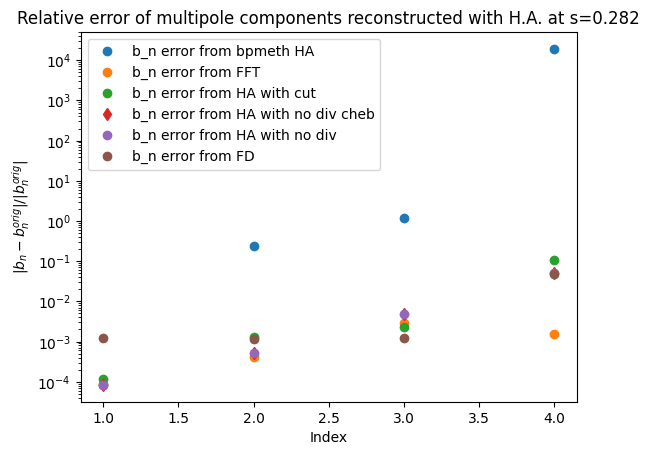

In [454]:
p=4#how many values to plot

#plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')

plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bn[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from bpmeth HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bnfft[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from FFT')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_cut[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from HA with cut' )
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_nodiv_cheb[:p])/b_eva(s_fixed)[:p], "d",label='b_n error from HA with no div cheb' )
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_nodiv[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from HA with no div' )
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-b_FD[:p,sindex])/b_eva(s_fixed)[:p], 'o', label='b_n error from FD' )
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.show()

bpmeth local harmonic analysis as function of s

In [455]:
svalues, bpmbofs, bpmerrorbofs = curlfieldmap.s_harmonics(order=4,rmin=rr[24], rmax=rmax, nr=40-24, ntheta=200,radius=0.007 )

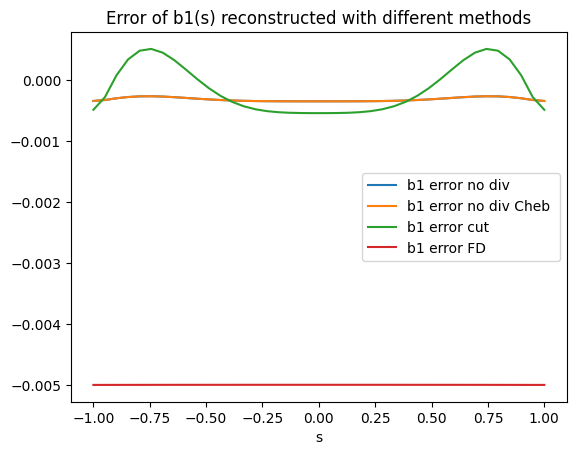

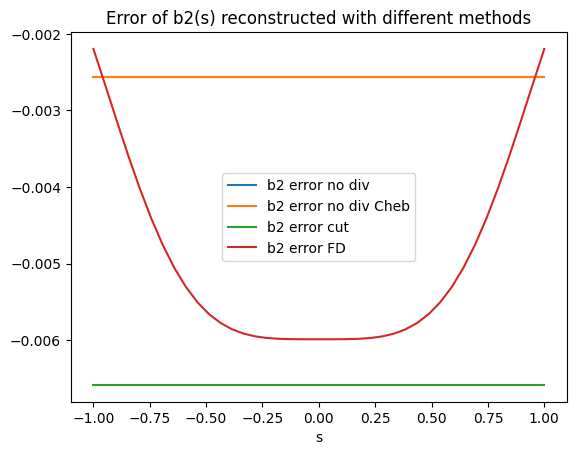

In [461]:
def LH_s_nodiv(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid_nodiv(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs
def LH_s_nodiv_cheb(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid_nodiv_cheb(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs

_, bofs_nodiv = LH_s_nodiv(fieldyix=curlyix,ss=ss, korder=4)
_, bofs_nodiv_cheb = LH_s_nodiv_cheb(fieldyix=curlyix,ss=ss, korder=4)

plt.plot(sss, bofs_nodiv[:,0]-b_eva(sss)[0], label='b1 error no div')
plt.plot(sss, (bofs_nodiv_cheb[:,0]-b_eva(sss)[0]), label='b1 error no div Cheb ')
plt.plot(sss, bofs_cut[:,0]-b_eva(sss)[0], label='b1 error cut')
plt.plot(sss, b_FD[0,:]-b_eva(sss)[0], label='b1 error FD' )
#plt.plot(sss, (bpmbofs[:,0]-b_eva(sss)[0])*1e-5, label='b1 error bpmeth HA *1e-5')
plt.legend()
plt.xlabel('s')
plt.title('Error of b1(s) reconstructed with different methods')
plt.show()


plt.plot(sss, bofs_nodiv[:,1]-b_eva(sss)[1], label='b2 error no div')
plt.plot(sss, (bofs_nodiv_cheb[:,1]-b_eva(sss)[1]), label='b2 error no div Cheb')
plt.plot(sss, bofs_cut[:,1]-b_eva(sss)[1], label='b2 error cut')
plt.plot(sss, b_FD[1,:]-b_eva(sss)[1], label='b2 error FD' )
#plt.plot(sss, (bpmbofs[:,1]-b_eva(sss)[1])*1e-4, label='b2 error bpmeth HA *1e-4')
plt.legend()
plt.xlabel('s')
plt.title('Error of b2(s) reconstructed with different methods')
plt.show()

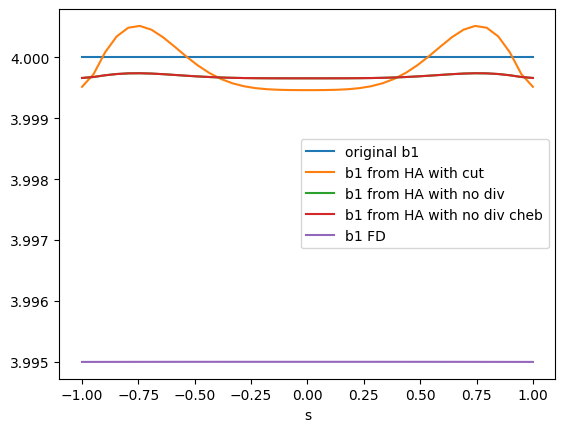

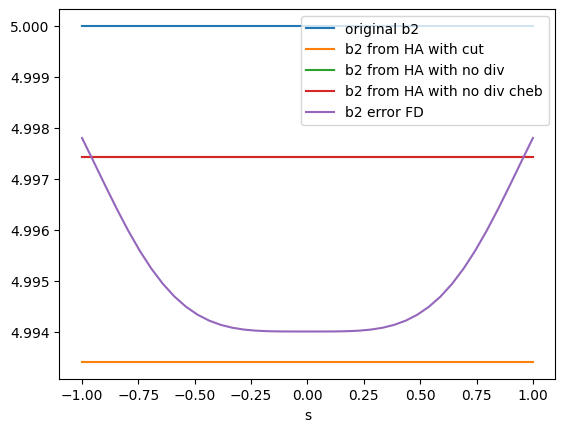

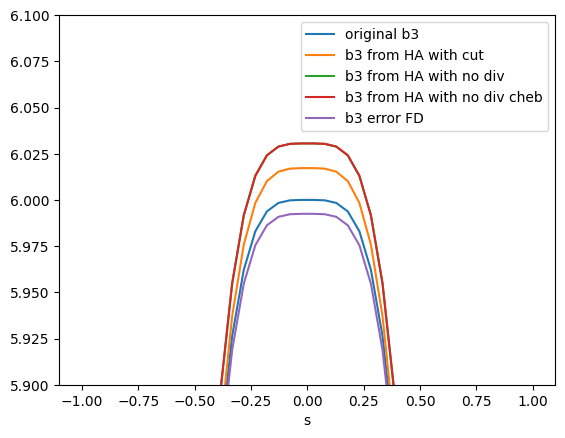

In [465]:
plt.plot(sss, b_eva(sss)[0], label="original b1")
#plt.plot(ss, bpmbofs[:,0], label="b1(s) from bpmeth")
plt.plot(sss, bofs_cut[:,0], label='b1 from HA with cut')
plt.plot(sss, bofs_nodiv[:,0], label='b1 from HA with no div')
plt.plot(sss, bofs_nodiv_cheb[:,0], label='b1 from HA with no div cheb')
plt.plot(sss, b_FD[0,:], label='b1 FD' )
plt.legend()
plt.xlabel('s')
plt.show()
plt.plot(ss, b_eva(ss)[1], label="original b2")
#plt.plot(ss, bpmbofs[:,1], label="b2(s) from bpmeth")
plt.plot(ss, bofs_cut[:,1], label='b2 from HA with cut')
plt.plot(ss, bofs_nodiv[:,1], label='b2 from HA with no div')
plt.plot(ss, bofs_nodiv_cheb[:,1], label='b2 from HA with no div cheb')
plt.plot(sss, b_FD[1,:], label='b2 error FD' )
plt.legend()
plt.xlabel('s')
plt.show()
plt.plot(ss, b_eva(ss)[2], label="original b3")
#plt.plot(ss, bpmbofs[:,2], label="b3(s) from bpmeth")
plt.plot(ss, bofs_cut[:,2], label='b3 from HA with cut')
plt.plot(ss, bofs_nodiv[:,2], label='b3 from HA with no div')
plt.plot(ss, bofs_nodiv_cheb[:,2], label='b3 from HA with no div cheb')
plt.plot(sss, b_FD[2,:], label='b3 error FD' )
plt.legend()
plt.xlabel('s')
plt.ylim((5.9,6.1))
plt.show()